In [6]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [7]:
### 1 load datasets
pd.set_option("display.max_columns", None)

df = pd.read_csv("training_dataset.csv")
df.head(10)

,id,name,age,city,income,score
0,1,Alice,29.0,New York,72000.0,88.0
1,2,Bob,NaN,Los Angeles,54000.0,72.0
2,3,Charlie,35.0,NaN,61000.0,81.0
3,4,David,42.0,Chicago,NaN,77.0
4,5,Eve,28.0,Los Angeles,59000.0,85.0
5,6,Frank,33.0,Houston,68000.0,90.0
6,7,Gina,27.0,Chicago,52000.0,69.0
7,8,Hank,41.0,Denver,75000.0,92.0
8,9,Ivy,31.0,New York,71000.0,87.0
9,10,Jack,NaN,Houston,64000.0,80.0


In [8]:
### 3 handling missing values
# 3.1 detect missing values
df.isna().sum()

id        0
name      2
age       9
city      8
income    6
score     2
dtype: int64

In [9]:
# 3.2 remove missing vaalues
df_missing = df.copy()
df_removed = df_missing.dropna()
df_removed.shape
df_removed.isna().sum()

id        0
name      0
age       0
city      0
income    0
score     0
dtype: int64

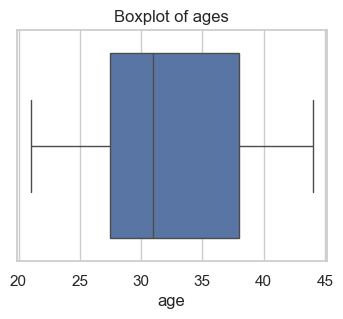

In [10]:
### 4 handling outliers
plt.figure(figsize=(4,3))
sns.boxplot(x=df_removed['age'])
plt.title("Boxplot of ages")
plt.show()

In [11]:
### 5 Normalization
df_removed[['age', 'income']].head()

,age,income
0,29.0,72000.0
4,28.0,59000.0
5,33.0,68000.0
6,27.0,52000.0
7,41.0,75000.0


In [13]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = df_removed[['age', 'income']].copy()
df_scaled[['age', 'income']] = scaler.fit_transform(df_scaled)
df_scaled.head()

,age,income
0,0.347826,0.750000
4,0.304348,0.388889
5,0.521739,0.638889
6,0.260870,0.194444
7,0.869565,0.833333


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_standardized = df_removed[['age', 'income']].copy()
df_standardized[['age', 'income']] = scaler.fit_transform(df_standardized)

df_standardized.head()

,age,income
0,-0.501489,0.755942
4,-0.662415,-0.581310
5,0.142213,0.344480
6,-0.823341,-1.301368
7,1.429619,1.064538


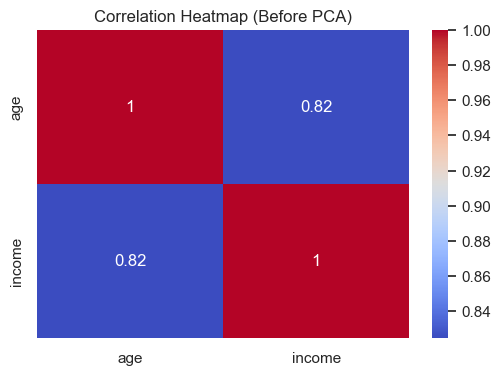

In [15]:
plt.figure(figsize=(6,4))
sns.heatmap(df_standardized[['age', 'income']].corr(), 
            annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Before PCA)")
plt.show()

In [16]:
### 6 data reduction
from sklearn.decomposition import PCA

X = df_standardized[['age', 'income']]

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.91244601 0.08755399]


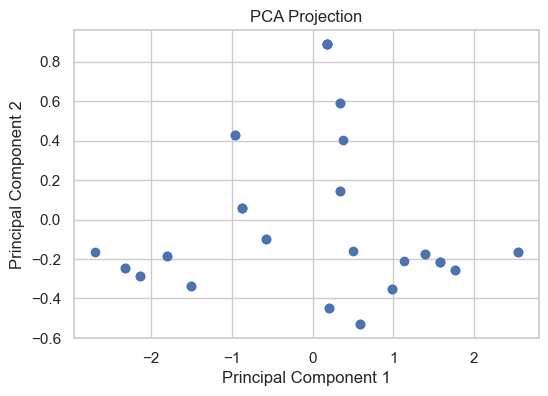

In [17]:
plt.figure(figsize=(6,4))
plt.scatter(principal_components[:,0], principal_components[:,1])
plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()